# Detección y Eliminación de Outliers – Idealista API

**Input:**
- `data/raw/idealistaAPI/preprocess/total_rent_cantabria.csv`
- `data/raw/idealistaAPI/preprocess/total_sales_cantabria.csv`

**Output:**
- `data/processed/idealistaAPI/total_rent_cantabria_outliers.csv`
- `data/processed/idealistaAPI/total_sale_cantabria_outliers.csv`

**Flujo:**
1. EDA exploratorio (distribuciones, scatter plots)
2. Comparativa de 4 métodos de detección de outliers
3. Pipeline final: **Regla fija → IQR ×1.5** (en secuencia, sobre copia de los originales)
4. Exportación de archivos limpios

---
## 0. Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
import warnings
import os
import glob

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (14, 5)

In [2]:
# ── Rutas ──────────────────────────────────────────────────────────────────
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))

RAW_RENT  = os.path.join(BASE_DIR, 'data', 'raw', 'idealistaAPI', 'preprocess', 'total_rent_cantabria.csv')
RAW_SALE  = os.path.join(BASE_DIR, 'data', 'raw', 'idealistaAPI', 'preprocess', 'total_sales_cantabria.csv')

OUT_DIR   = os.path.join(BASE_DIR, 'data', 'processed', 'idealistaAPI')
OUT_RENT  = os.path.join(OUT_DIR, 'total_rent_cantabria_outliers.csv')
OUT_SALE  = os.path.join(OUT_DIR, 'total_sale_cantabria_outliers.csv')

os.makedirs(OUT_DIR, exist_ok=True)
print(f"Base dir: {BASE_DIR}")
print(f"Input rent : {RAW_RENT}")
print(f"Input sale : {RAW_SALE}")
print(f"Output dir : {OUT_DIR}")

Base dir: /Users/sitomachucas/Documents/BezanillaSL
Input rent : /Users/sitomachucas/Documents/BezanillaSL/data/raw/idealistaAPI/preprocess/total_rent_cantabria.csv
Input sale : /Users/sitomachucas/Documents/BezanillaSL/data/raw/idealistaAPI/preprocess/total_sales_cantabria.csv
Output dir : /Users/sitomachucas/Documents/BezanillaSL/data/processed/idealistaAPI


---
## 1. Carga de datos

In [3]:
rent = pd.read_csv(RAW_RENT)
sale = pd.read_csv(RAW_SALE)

# Columnas clave para análisis de outliers
KEY_COLS = ['price', 'size', 'priceByArea', 'rooms', 'bathrooms']

print(f"Rent → {rent.shape[0]:,} registros")
print(f"Sale → {sale.shape[0]:,} registros")

# Forzar numérico en columnas clave
for col in KEY_COLS:
    if col in rent.columns:
        rent[col] = pd.to_numeric(rent[col], errors='coerce')
    if col in sale.columns:
        sale[col] = pd.to_numeric(sale[col], errors='coerce')

Rent → 875 registros
Sale → 2,851 registros


In [4]:
# Estadísticas descriptivas básicas
print("=== ALQUILER ===")
display(rent[KEY_COLS].describe().round(2))
print("\n=== VENTA ===")
display(sale[KEY_COLS].describe().round(2))

=== ALQUILER ===


,price,size,priceByArea,rooms,bathrooms
count,875.00,875.00,875.00,875.00,875.00
mean,1317.87,97.21,14.97,2.38,1.58
std,1123.14,76.98,9.75,1.01,0.77
min,487.00,25.00,2.00,0.00,1.00
25%,800.00,65.00,10.00,2.00,1.00
50%,950.00,80.00,12.00,2.00,1.00
75%,1400.00,105.00,15.00,3.00,2.00
max,18000.00,1430.00,81.00,9.00,8.00



=== VENTA ===


,price,size,priceByArea,rooms,bathrooms
count,2851.00,2851.00,2851.00,2851.00,2851.00
mean,387984.03,175.66,2709.21,3.29,2.11
std,323940.18,209.95,1428.84,1.71,1.31
min,21000.00,25.00,75.00,0.00,0.00
25%,195000.00,76.00,1734.00,2.00,1.00
50%,300000.00,109.00,2542.00,3.00,2.00
75%,461000.00,214.00,3417.00,4.00,3.00
max,3600000.00,6300.00,13071.00,20.00,16.00


---
## 2. EDA – Análisis Exploratorio

### 2.1 Distribuciones de precio y superficie

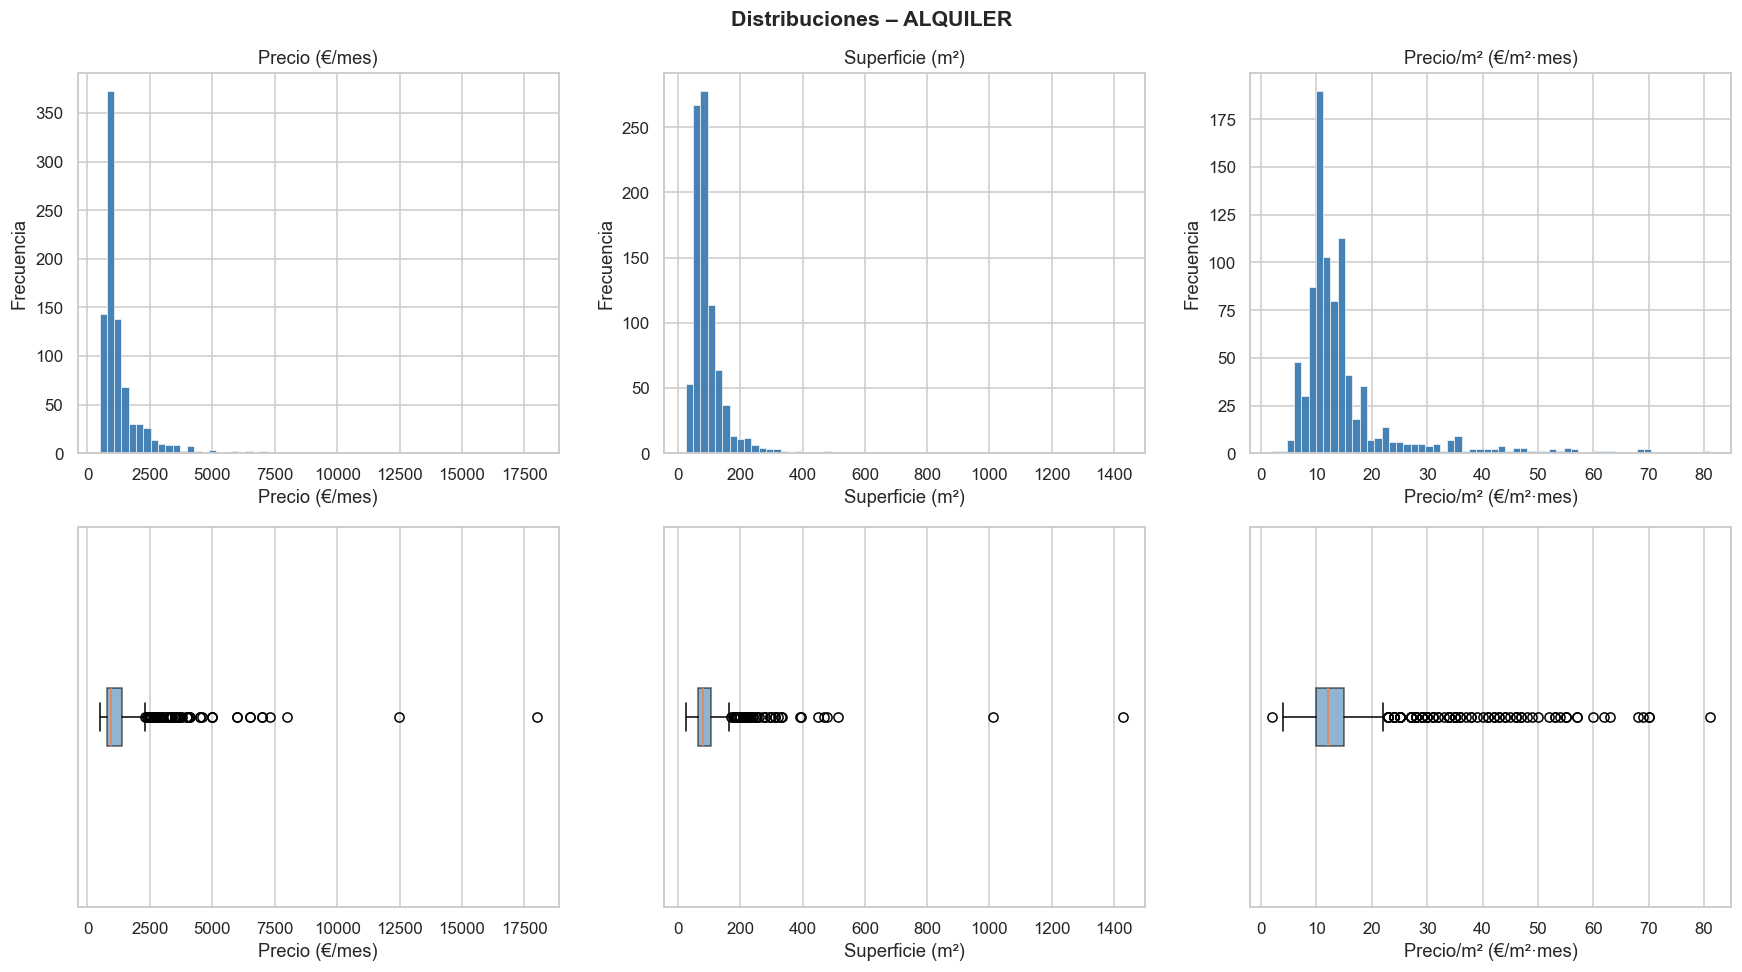

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribuciones – ALQUILER', fontsize=14, fontweight='bold')

cols_plot = ['price', 'size', 'priceByArea']
labels    = ['Precio (€/mes)', 'Superficie (m²)', 'Precio/m² (€/m²·mes)']

for i, (col, label) in enumerate(zip(cols_plot, labels)):
    data = rent[col].dropna()
    # Histograma
    axes[0, i].hist(data, bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
    axes[0, i].set_title(label)
    axes[0, i].set_xlabel(label)
    axes[0, i].set_ylabel('Frecuencia')
    # Boxplot
    axes[1, i].boxplot(data, vert=False, patch_artist=True,
                       boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[1, i].set_xlabel(label)
    axes[1, i].set_yticks([])

plt.tight_layout()
plt.show()

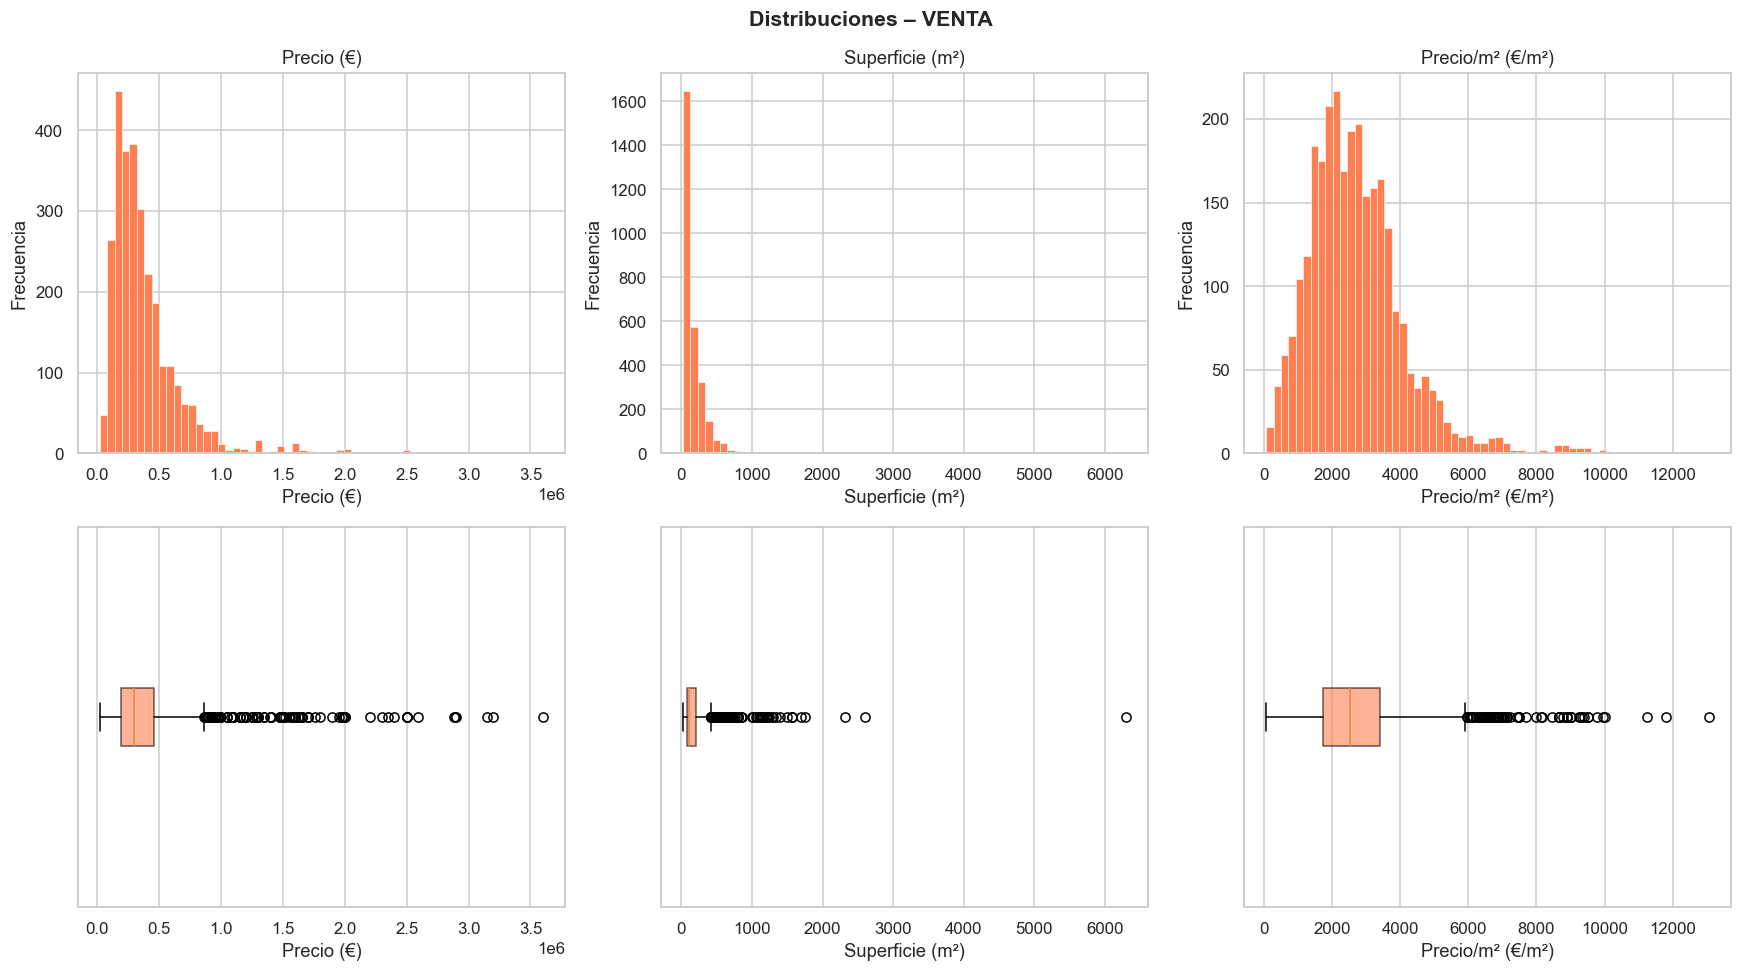

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribuciones – VENTA', fontsize=14, fontweight='bold')

cols_plot = ['price', 'size', 'priceByArea']
labels    = ['Precio (€)', 'Superficie (m²)', 'Precio/m² (€/m²)']

for i, (col, label) in enumerate(zip(cols_plot, labels)):
    data = sale[col].dropna()
    axes[0, i].hist(data, bins=60, color='coral', edgecolor='white', linewidth=0.4)
    axes[0, i].set_title(label)
    axes[0, i].set_xlabel(label)
    axes[0, i].set_ylabel('Frecuencia')
    axes[1, i].boxplot(data, vert=False, patch_artist=True,
                       boxprops=dict(facecolor='coral', alpha=0.6))
    axes[1, i].set_xlabel(label)
    axes[1, i].set_yticks([])

plt.tight_layout()
plt.show()

### 2.2 Scatter plots – Precio vs Superficie

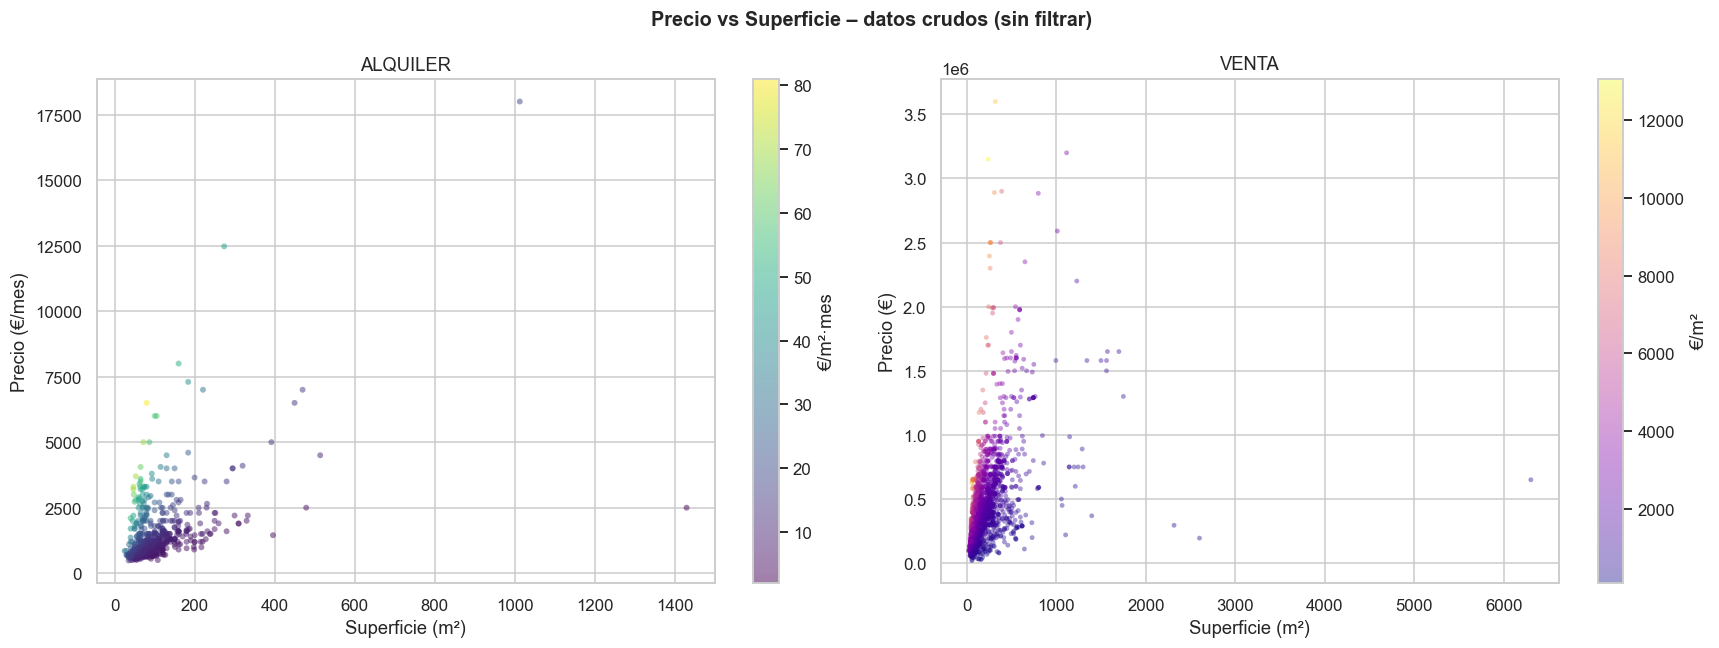

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Precio vs Superficie – datos crudos (sin filtrar)', fontsize=13, fontweight='bold')

# Alquiler
r = rent.dropna(subset=['price', 'size'])
sc1 = axes[0].scatter(r['size'], r['price'],
                      c=r['priceByArea'], cmap='viridis',
                      alpha=0.5, s=15, edgecolors='none')
plt.colorbar(sc1, ax=axes[0], label='€/m²·mes')
axes[0].set_title('ALQUILER')
axes[0].set_xlabel('Superficie (m²)')
axes[0].set_ylabel('Precio (€/mes)')

# Venta
s = sale.dropna(subset=['price', 'size'])
sc2 = axes[1].scatter(s['size'], s['price'],
                      c=s['priceByArea'], cmap='plasma',
                      alpha=0.4, s=10, edgecolors='none')
plt.colorbar(sc2, ax=axes[1], label='€/m²')
axes[1].set_title('VENTA')
axes[1].set_xlabel('Superficie (m²)')
axes[1].set_ylabel('Precio (€)')

plt.tight_layout()
plt.show()

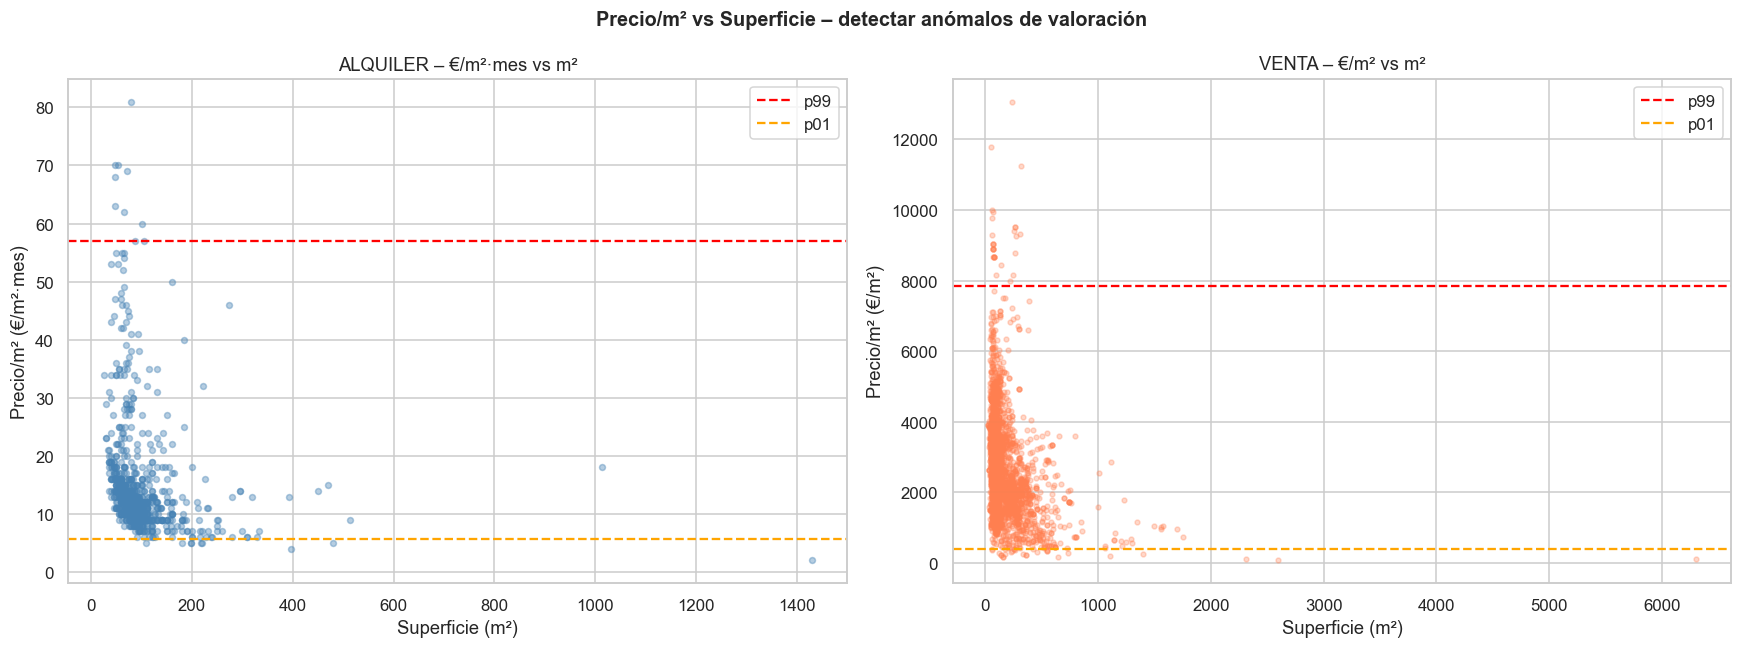

In [8]:
# Scatter precio/m² vs superficie (revela outliers de valoración)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Precio/m² vs Superficie – detectar anómalos de valoración', fontsize=13, fontweight='bold')

r = rent.dropna(subset=['priceByArea', 'size'])
axes[0].scatter(r['size'], r['priceByArea'], alpha=0.4, s=15, color='steelblue')
axes[0].axhline(r['priceByArea'].quantile(0.99), color='red', linestyle='--', label='p99')
axes[0].axhline(r['priceByArea'].quantile(0.01), color='orange', linestyle='--', label='p01')
axes[0].set_title('ALQUILER – €/m²·mes vs m²')
axes[0].set_xlabel('Superficie (m²)')
axes[0].set_ylabel('Precio/m² (€/m²·mes)')
axes[0].legend()

s = sale.dropna(subset=['priceByArea', 'size'])
axes[1].scatter(s['size'], s['priceByArea'], alpha=0.3, s=10, color='coral')
axes[1].axhline(s['priceByArea'].quantile(0.99), color='red', linestyle='--', label='p99')
axes[1].axhline(s['priceByArea'].quantile(0.01), color='orange', linestyle='--', label='p01')
axes[1].set_title('VENTA – €/m² vs m²')
axes[1].set_xlabel('Superficie (m²)')
axes[1].set_ylabel('Precio/m² (€/m²)')
axes[1].legend()

plt.tight_layout()
plt.show()

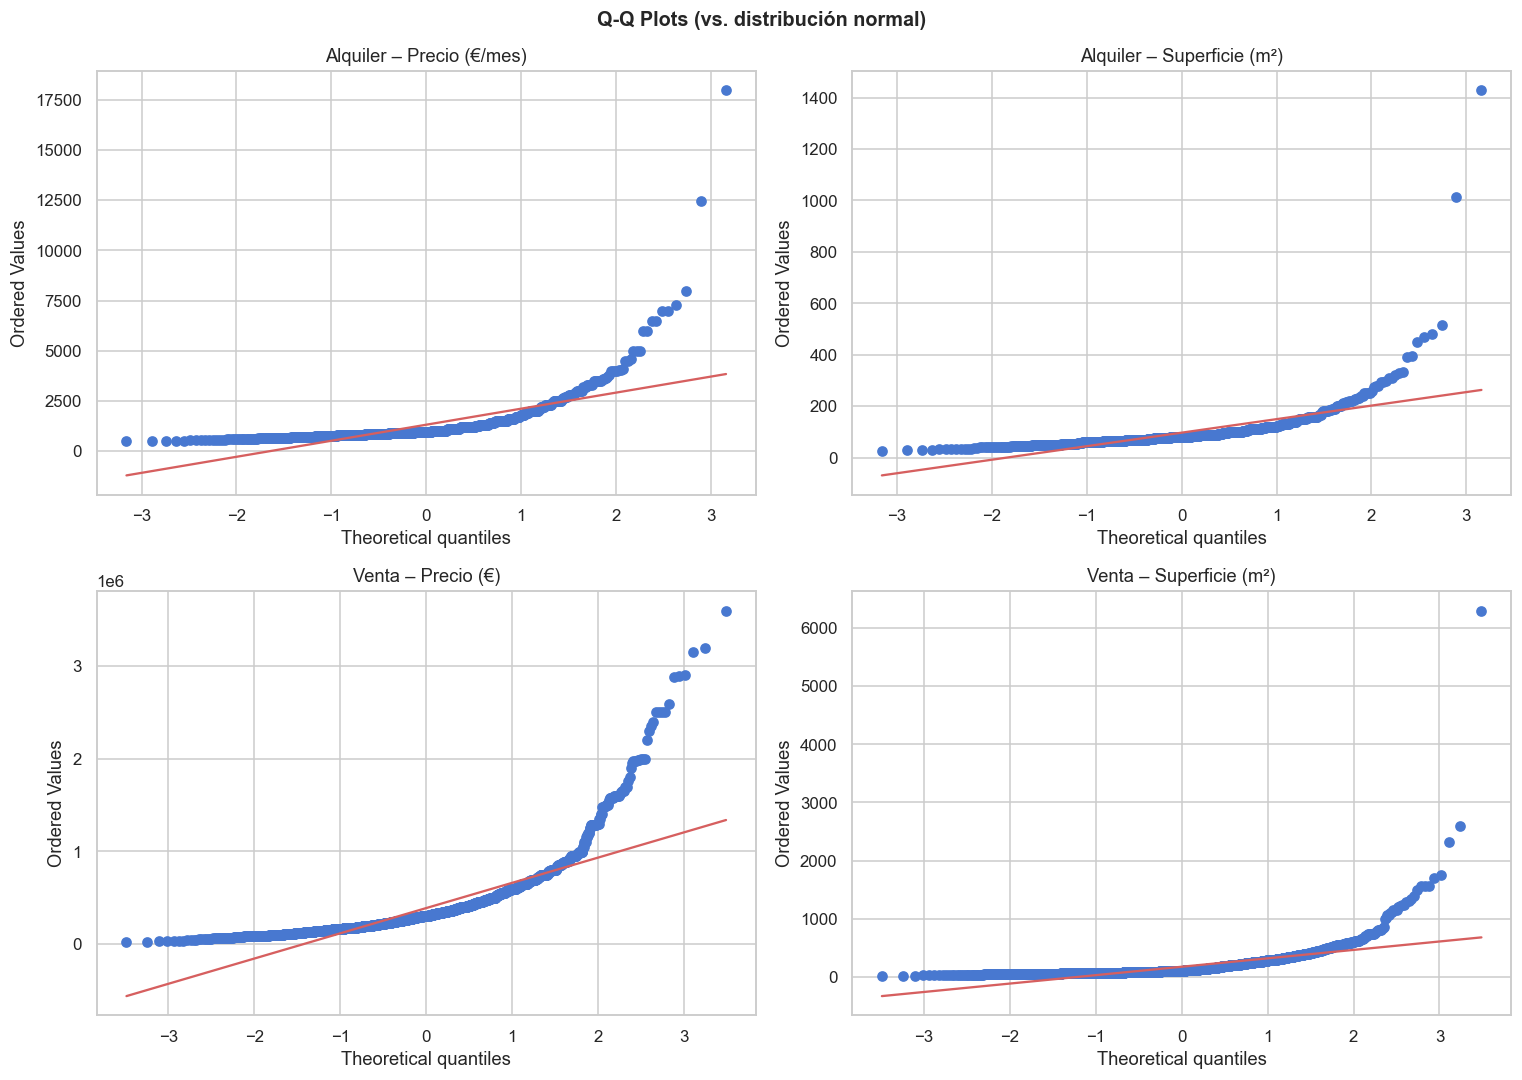

INTERPRETACIÓN Q-Q:
- Los puntos se alejan mucho de la línea diagonal → las distribuciones NO son normales.
- Cola derecha muy pronunciada → presencia de outliers altos (viviendas de lujo o errores de datos).
- Esto es CLAVE para elegir el método: la regla 3-sigma asume normalidad, de ahí que elimine demasiado.


In [9]:
# Q-Q plots para ver alejamiento de la normalidad
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Q-Q Plots (vs. distribución normal)', fontsize=13, fontweight='bold')

datasets = [
    (rent['price'].dropna(),       axes[0,0], 'Alquiler – Precio (€/mes)'),
    (rent['size'].dropna(),        axes[0,1], 'Alquiler – Superficie (m²)'),
    (sale['price'].dropna(),       axes[1,0], 'Venta – Precio (€)'),
    (sale['size'].dropna(),        axes[1,1], 'Venta – Superficie (m²)'),
]

for data, ax, title in datasets:
    stats.probplot(data, dist='norm', plot=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

print("""INTERPRETACIÓN Q-Q:
- Los puntos se alejan mucho de la línea diagonal → las distribuciones NO son normales.
- Cola derecha muy pronunciada → presencia de outliers altos (viviendas de lujo o errores de datos).
- Esto es CLAVE para elegir el método: la regla 3-sigma asume normalidad, de ahí que elimine demasiado.""")

In [10]:
# Skewness y curtosis
print("=== ALQUILER – asimetría y curtosis ===")
for col in ['price', 'size', 'priceByArea']:
    d = rent[col].dropna()
    print(f"  {col:15s}  skew={d.skew():.2f}  kurt={d.kurtosis():.2f}")

print("\n=== VENTA – asimetría y curtosis ===")
for col in ['price', 'size', 'priceByArea']:
    d = sale[col].dropna()
    print(f"  {col:15s}  skew={d.skew():.2f}  kurt={d.kurtosis():.2f}")

print("""\nINTERPRETACIÓN:
- skew > 1  → cola derecha larga (outliers hacia arriba)
- kurt > 3  → distribución leptocúrtica, con colas pesadas""")

=== ALQUILER – asimetría y curtosis ===
  price            skew=6.51  kurt=71.26
  size             skew=8.96  kurt=127.95
  priceByArea      skew=3.05  kurt=11.11

=== VENTA – asimetría y curtosis ===
  price            skew=3.42  kurt=18.48
  size             skew=11.37  kurt=270.62
  priceByArea      skew=1.49  kurt=4.75

INTERPRETACIÓN:
- skew > 1  → cola derecha larga (outliers hacia arriba)
- kurt > 3  → distribución leptocúrtica, con colas pesadas


---
## 3. Métodos de detección de outliers

Se comparan 4 métodos con diferente agresividad y filosofía:

| # | Método | Asume normalidad | Variables | Agresividad |
|---|--------|-----------------|-----------|-------------|
| 1 | **Regla fija** | No | Univariante | Configurable |
| 2 | **IQR (1.5×)** | No | Univariante | Media |
| 3 | **Z-score sobre log** | Sí (en log) | Univariante | Baja |
| 4 | **Isolation Forest** | No | Multivariante | Alta (configurable) |

Variables analizadas: `price`, `size`, `priceByArea`

In [11]:
# ── Función auxiliar: resumen de registros eliminados ─────────────────────
def resumen(nombre, df_orig, mask_outlier):
    n_out = mask_outlier.sum()
    pct   = 100 * n_out / len(df_orig)
    print(f"  [{nombre}]  outliers={n_out:,}  ({pct:.1f}%)  → quedan {len(df_orig)-n_out:,}")
    return mask_outlier

### Método 1 – Regla fija (umbrales de dominio)

In [12]:
# ── Umbrales configurables ────────────────────────────────────────────────
# Ajusta estos valores según el conocimiento de dominio del mercado cántabro
RENT_PRICE_MIN,  RENT_PRICE_MAX  = 200,   5_000    # €/mes
SALE_PRICE_MIN,  SALE_PRICE_MAX  = 30_000, 2_000_000  # €
RENT_SIZE_MIN,   RENT_SIZE_MAX   = 15,    400      # m²
SALE_SIZE_MIN,   SALE_SIZE_MAX   = 15,    600      # m²
RENT_PBM_MIN,    RENT_PBM_MAX    = 1,     50       # €/m²·mes
SALE_PBM_MIN,    SALE_PBM_MAX    = 300,   10_000   # €/m²

def mask_regla_fija_rent(df):
    return (
        df['price'].between(RENT_PRICE_MIN, RENT_PRICE_MAX) &
        df['size'].between(RENT_SIZE_MIN, RENT_SIZE_MAX) &
        (df['priceByArea'].isna() | df['priceByArea'].between(RENT_PBM_MIN, RENT_PBM_MAX))
    )

def mask_regla_fija_sale(df):
    return (
        df['price'].between(SALE_PRICE_MIN, SALE_PRICE_MAX) &
        df['size'].between(SALE_SIZE_MIN, SALE_SIZE_MAX) &
        (df['priceByArea'].isna() | df['priceByArea'].between(SALE_PBM_MIN, SALE_PBM_MAX))
    )

print("REGLA FIJA:")
m1_rent_out = ~mask_regla_fija_rent(rent)
m1_sale_out = ~mask_regla_fija_sale(sale)
resumen('Alquiler', rent, m1_rent_out)
resumen('Venta',    sale, m1_sale_out)

REGLA FIJA:
  [Alquiler]  outliers=27  (3.1%)  → quedan 848
  [Venta]  outliers=86  (3.0%)  → quedan 2,765


0       False
1       False
2       False
3       False
4       False
        ...  
2846    False
2847    False
2848    False
2849    False
2850    False
Length: 2851, dtype: bool

### Método 2 – IQR (1.5× y 3×)

In [13]:
def mask_iqr(df, cols, factor=1.5):
    """Devuelve máscara True donde el registro es outlier en AL MENOS una columna."""
    mask = pd.Series(False, index=df.index)
    for col in cols:
        d = df[col].dropna()
        q1, q3 = d.quantile(0.25), d.quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - factor * iqr, q3 + factor * iqr
        mask |= df[col].notna() & ((df[col] < lower) | (df[col] > upper))
    return mask

iqr_cols = ['price', 'size', 'priceByArea']

print("IQR ×1.5 (estándar):")
m2a_rent_out = mask_iqr(rent, iqr_cols, 1.5)
m2a_sale_out = mask_iqr(sale, iqr_cols, 1.5)
resumen('Alquiler', rent, m2a_rent_out)
resumen('Venta',    sale, m2a_sale_out)

print("\nIQR ×3.0 (conservador):")
m2b_rent_out = mask_iqr(rent, iqr_cols, 3.0)
m2b_sale_out = mask_iqr(sale, iqr_cols, 3.0)
resumen('Alquiler', rent, m2b_rent_out)
resumen('Venta',    sale, m2b_sale_out)

IQR ×1.5 (estándar):
  [Alquiler]  outliers=167  (19.1%)  → quedan 708
  [Venta]  outliers=326  (11.4%)  → quedan 2,525

IQR ×3.0 (conservador):
  [Alquiler]  outliers=96  (11.0%)  → quedan 779
  [Venta]  outliers=126  (4.4%)  → quedan 2,725


0       False
1       False
2       False
3       False
4       False
        ...  
2846     True
2847    False
2848    False
2849    False
2850    False
Length: 2851, dtype: bool

### Método 3 – Z-score sobre transformación logarítmica

In [14]:
def mask_zscore_log(df, cols, threshold=3.0):
    """Z-score sobre log(x) para manejar distribuciones sesgadas a la derecha."""
    mask = pd.Series(False, index=df.index)
    for col in cols:
        series = df[col]
        valid  = series[series > 0].dropna()
        log_v  = np.log(valid)
        z      = (log_v - log_v.mean()) / log_v.std()
        outlier_idx = z[z.abs() > threshold].index
        mask |= df.index.isin(outlier_idx)
    return mask

log_cols = ['price', 'size', 'priceByArea']

print("Z-score log – umbral 3.0σ:")
m3a_rent_out = mask_zscore_log(rent, log_cols, 3.0)
m3a_sale_out = mask_zscore_log(sale, log_cols, 3.0)
resumen('Alquiler', rent, m3a_rent_out)
resumen('Venta',    sale, m3a_sale_out)

print("\nZ-score log – umbral 2.5σ:")
m3b_rent_out = mask_zscore_log(rent, log_cols, 2.5)
m3b_sale_out = mask_zscore_log(sale, log_cols, 2.5)
resumen('Alquiler', rent, m3b_rent_out)
resumen('Venta',    sale, m3b_sale_out)

Z-score log – umbral 3.0σ:
  [Alquiler]  outliers=30  (3.4%)  → quedan 845
  [Venta]  outliers=60  (2.1%)  → quedan 2,791

Z-score log – umbral 2.5σ:
  [Alquiler]  outliers=58  (6.6%)  → quedan 817
  [Venta]  outliers=127  (4.5%)  → quedan 2,724


0       False
1       False
2       False
3       False
4       False
        ...  
2846    False
2847    False
2848    False
2849    False
2850    False
Length: 2851, dtype: bool

### Método 4 – Isolation Forest (multivariante)

In [15]:
def mask_isolation_forest(df, cols, contamination=0.05, random_state=42):
    """Isolation Forest multivariante. contamination = fracción esperada de outliers."""
    sub = df[cols].copy()
    sub = sub.fillna(sub.median())
    clf = IsolationForest(contamination=contamination, random_state=random_state)
    preds = clf.fit_predict(sub)
    return pd.Series(preds == -1, index=df.index)

if_cols = ['price', 'size', 'priceByArea']

print("Isolation Forest – contamination=0.05 (5%):")
m4a_rent_out = mask_isolation_forest(rent, if_cols, contamination=0.05)
m4a_sale_out = mask_isolation_forest(sale, if_cols, contamination=0.05)
resumen('Alquiler', rent, m4a_rent_out)
resumen('Venta',    sale, m4a_sale_out)

print("\nIsolation Forest – contamination=0.02 (2%):")
m4b_rent_out = mask_isolation_forest(rent, if_cols, contamination=0.02)
m4b_sale_out = mask_isolation_forest(sale, if_cols, contamination=0.02)
resumen('Alquiler', rent, m4b_rent_out)
resumen('Venta',    sale, m4b_sale_out)

Isolation Forest – contamination=0.05 (5%):
  [Alquiler]  outliers=44  (5.0%)  → quedan 831
  [Venta]  outliers=143  (5.0%)  → quedan 2,708

Isolation Forest – contamination=0.02 (2%):
  [Alquiler]  outliers=18  (2.1%)  → quedan 857
  [Venta]  outliers=57  (2.0%)  → quedan 2,794


0       False
1       False
2       False
3       False
4       False
        ...  
2846    False
2847    False
2848    False
2849    False
2850    False
Length: 2851, dtype: bool

---
## 4. Comparativa visual de métodos

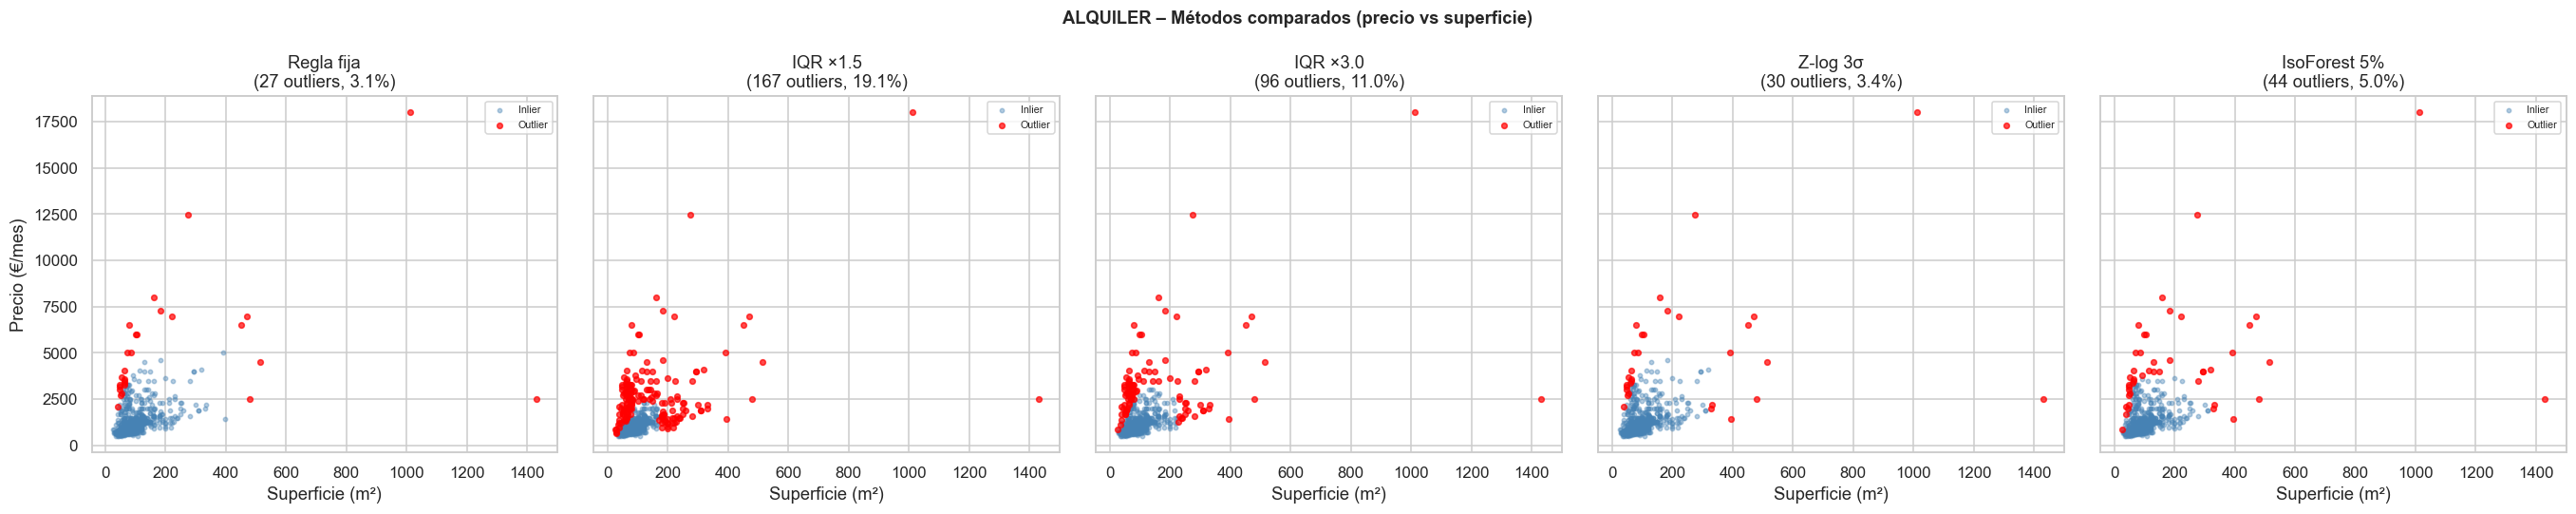

In [16]:
def plot_comparison(df, masks_dict, xcol, ycol, title, xlabel, ylabel):
    """Scatter grid: inliers en azul/verde, outliers en rojo para cada método."""
    n = len(masks_dict)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5), sharey=True)
    fig.suptitle(title, fontsize=12, fontweight='bold')

    sub = df.dropna(subset=[xcol, ycol])
    for ax, (name, mask_out) in zip(axes, masks_dict.items()):
        m = mask_out.reindex(sub.index).fillna(False)
        ax.scatter(sub.loc[~m, xcol], sub.loc[~m, ycol],
                   s=8, alpha=0.4, color='steelblue', label='Inlier')
        ax.scatter(sub.loc[ m, xcol], sub.loc[ m, ycol],
                   s=14, alpha=0.7, color='red', label='Outlier')
        n_out = m.sum()
        ax.set_title(f"{name}\n({n_out} outliers, {100*n_out/len(sub):.1f}%)")
        ax.set_xlabel(xlabel)
        if ax == axes[0]:
            ax.set_ylabel(ylabel)
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

# ── Alquiler: precio vs superficie ────────────────────────────────────────
masks_rent = {
    'Regla fija':       m1_rent_out,
    'IQR ×1.5':         m2a_rent_out,
    'IQR ×3.0':         m2b_rent_out,
    'Z-log 3σ':         m3a_rent_out,
    'IsoForest 5%':     m4a_rent_out,
}

plot_comparison(rent, masks_rent, 'size', 'price',
                'ALQUILER – Métodos comparados (precio vs superficie)',
                'Superficie (m²)', 'Precio (€/mes)')

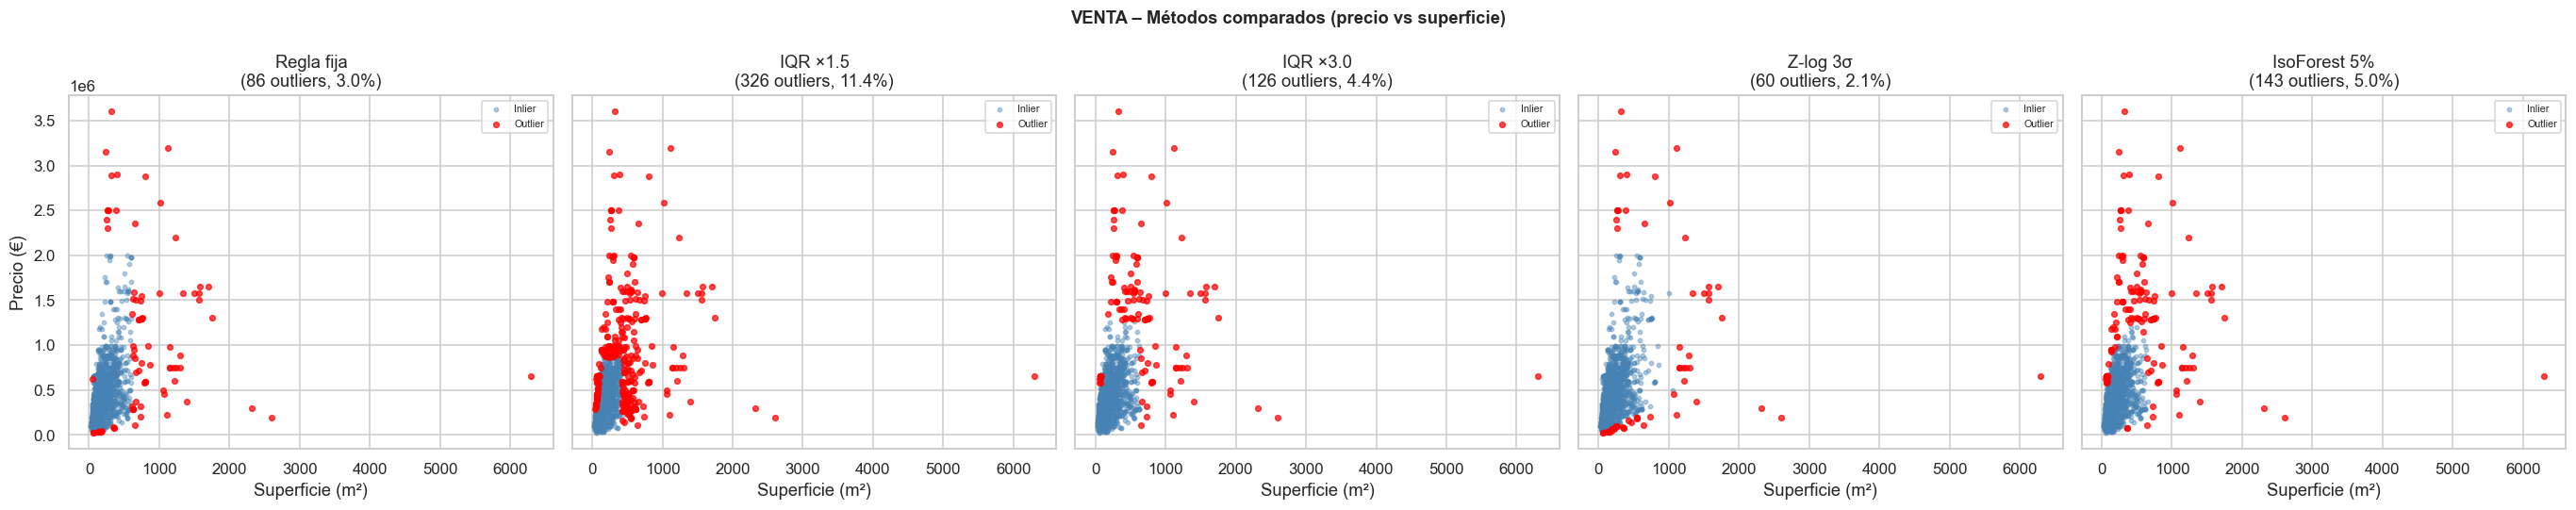

In [17]:
# ── Venta: precio vs superficie ───────────────────────────────────────────
masks_sale = {
    'Regla fija':       m1_sale_out,
    'IQR ×1.5':         m2a_sale_out,
    'IQR ×3.0':         m2b_sale_out,
    'Z-log 3σ':         m3a_sale_out,
    'IsoForest 5%':     m4a_sale_out,
}

plot_comparison(sale, masks_sale, 'size', 'price',
                'VENTA – Métodos comparados (precio vs superficie)',
                'Superficie (m²)', 'Precio (€)')

In [18]:
# ── Tabla resumen ─────────────────────────────────────────────────────────
summary_rows = []
for name, m_r, m_s in [
    ('Regla fija',      m1_rent_out,  m1_sale_out),
    ('IQR ×1.5',        m2a_rent_out, m2a_sale_out),
    ('IQR ×3.0',        m2b_rent_out, m2b_sale_out),
    ('Z-log 3.0σ',      m3a_rent_out, m3a_sale_out),
    ('Z-log 2.5σ',      m3b_rent_out, m3b_sale_out),
    ('IsoForest 5%',    m4a_rent_out, m4a_sale_out),
    ('IsoForest 2%',    m4b_rent_out, m4b_sale_out),
]:
    summary_rows.append({
        'Método':                name,
        'Rent outliers':         int(m_r.sum()),
        'Rent %':                f"{100*m_r.sum()/len(rent):.1f}%",
        'Rent restantes':        len(rent) - int(m_r.sum()),
        'Sale outliers':         int(m_s.sum()),
        'Sale %':                f"{100*m_s.sum()/len(sale):.1f}%",
        'Sale restantes':        len(sale) - int(m_s.sum()),
    })

display(pd.DataFrame(summary_rows).set_index('Método'))

,Rent outliers,Rent %,Rent restantes,Sale outliers,Sale %,Sale restantes
Método,,,,,,
Regla fija,27,3.1%,848,86,3.0%,2765
IQR ×1.5,167,19.1%,708,326,11.4%,2525
IQR ×3.0,96,11.0%,779,126,4.4%,2725
Z-log 3.0σ,30,3.4%,845,60,2.1%,2791
Z-log 2.5σ,58,6.6%,817,127,4.5%,2724
IsoForest 5%,44,5.0%,831,143,5.0%,2708
IsoForest 2%,18,2.1%,857,57,2.0%,2794


---
## 5. Recomendación y discusión

### Por qué el Z-score clásico elimina demasiado
Los precios inmobiliarios siguen una distribución **log-normal**, no normal: hay una cola derecha larga (pisos de lujo, villas, etc.) que es real y no es ruido. Aplicar Z-score sobre la escala original hace que el 30–40% de los datos queden fuera de ±3σ aunque muchos sean legítimos.

### Comparativa de métodos

| Método | Ventaja | Inconveniente | Mejor para |
|--------|---------|--------------|------------|
| **Regla fija** | Interpretable, controlable por experto | Requiere revisar umbrales manualmente con cada actualización | Conocimiento de dominio sólido |
| **IQR ×1.5** | Robusto, sin supuestos de distribución | Agresivo con colas largas (mercado de lujo puede eliminarse) | ✅ **Opción elegida: elimina más ruido** |
| **IQR ×3.0** | Más conservador, elimina solo los muy extremos | Puede dejar algunos errores de datos | Conjuntos con mucha vivienda de lujo legítima |
| **Z-log 3σ** | Respetuoso con distribuciones sesgadas | Requiere valores positivos; elimina menos que IQR ×1.5 | Buena opción con skewness alto |
| **Isolation Forest** | Multivariante, detecta combinaciones anómalas | Menos interpretable, depende de `contamination` | Detección de fraude/error sistémico |

### Pipeline elegido: Regla fija → IQR ×1.5

Se aplican **dos pasos en secuencia** sobre una copia de los datos originales:

1. **Regla fija** — primera barrera: elimina errores graves de entrada (precio = 0, tamaño imposible, ratios absurdos). Los umbrales son configurables y reflejan conocimiento del mercado cántabro.
2. **IQR ×1.5** — segunda pasada: sobre el subconjunto ya filtrado, detecta los registros que aún se alejan estadísticamente en `price`, `size` o `priceByArea`. Al aplicar primero la regla fija, los valores extremos legítimos de alta gama ya quedan dentro de los umbrales de dominio, por lo que IQR ×1.5 actúa sobre una distribución más limpia sin eliminar vivienda cara legítima.

Esta combinación maximiza la eliminación de ruido estadístico manteniendo la coherencia de dominio.

---
## 6. Pipeline final: Regla fija → IQR ×1.5 y exportación

In [19]:
# ── Paso 0: copias de los originales (no se modifican rent/sale) ──────────
rent_pipe = rent.copy()
sale_pipe = sale.copy()

print(f"Original → Alquiler: {len(rent_pipe):,} registros | Venta: {len(sale_pipe):,} registros")

# ── Paso 1: Regla fija ────────────────────────────────────────────────────
# Los umbrales son los mismos definidos en la sección 3 (ajústalos si es necesario)
rent_paso1 = rent_pipe[mask_regla_fija_rent(rent_pipe)].reset_index(drop=True)
sale_paso1 = sale_pipe[mask_regla_fija_sale(sale_pipe)].reset_index(drop=True)

elim_r1 = len(rent_pipe) - len(rent_paso1)
elim_s1 = len(sale_pipe) - len(sale_paso1)
print(f"\nPaso 1 – Regla fija:")
print(f"  Alquiler: {len(rent_pipe):,} → {len(rent_paso1):,}  (eliminados: {elim_r1:,})")
print(f"  Venta   : {len(sale_pipe):,} → {len(sale_paso1):,}  (eliminados: {elim_s1:,})")

# ── Paso 2: IQR ×1.5 sobre el resultado del paso 1 ───────────────────────
IQR_COLS   = ['price', 'size', 'priceByArea']
IQR_FACTOR = 1.5

mask_iqr_rent2 = mask_iqr(rent_paso1, IQR_COLS, IQR_FACTOR)
mask_iqr_sale2 = mask_iqr(sale_paso1, IQR_COLS, IQR_FACTOR)

rent_clean = rent_paso1[~mask_iqr_rent2].reset_index(drop=True)
sale_clean = sale_paso1[~mask_iqr_sale2].reset_index(drop=True)

elim_r2 = len(rent_paso1) - len(rent_clean)
elim_s2 = len(sale_paso1) - len(sale_clean)
print(f"\nPaso 2 – IQR ×{IQR_FACTOR} sobre columnas {IQR_COLS}:")
print(f"  Alquiler: {len(rent_paso1):,} → {len(rent_clean):,}  (eliminados: {elim_r2:,})")
print(f"  Venta   : {len(sale_paso1):,} → {len(sale_clean):,}  (eliminados: {elim_s2:,})")

print(f"\nTOTAL eliminados:")
print(f"  Alquiler: {elim_r1 + elim_r2:,}  ({100*(elim_r1+elim_r2)/len(rent_pipe):.1f}%)")
print(f"  Venta   : {elim_s1 + elim_s2:,}  ({100*(elim_s1+elim_s2)/len(sale_pipe):.1f}%)")

Original → Alquiler: 875 registros | Venta: 2,851 registros

Paso 1 – Regla fija:
  Alquiler: 875 → 848  (eliminados: 27)
  Venta   : 2,851 → 2,765  (eliminados: 86)

Paso 2 – IQR ×1.5 sobre columnas ['price', 'size', 'priceByArea']:
  Alquiler: 848 → 702  (eliminados: 146)
  Venta   : 2,765 → 2,469  (eliminados: 296)

TOTAL eliminados:
  Alquiler: 173  (19.8%)
  Venta   : 382  (13.4%)


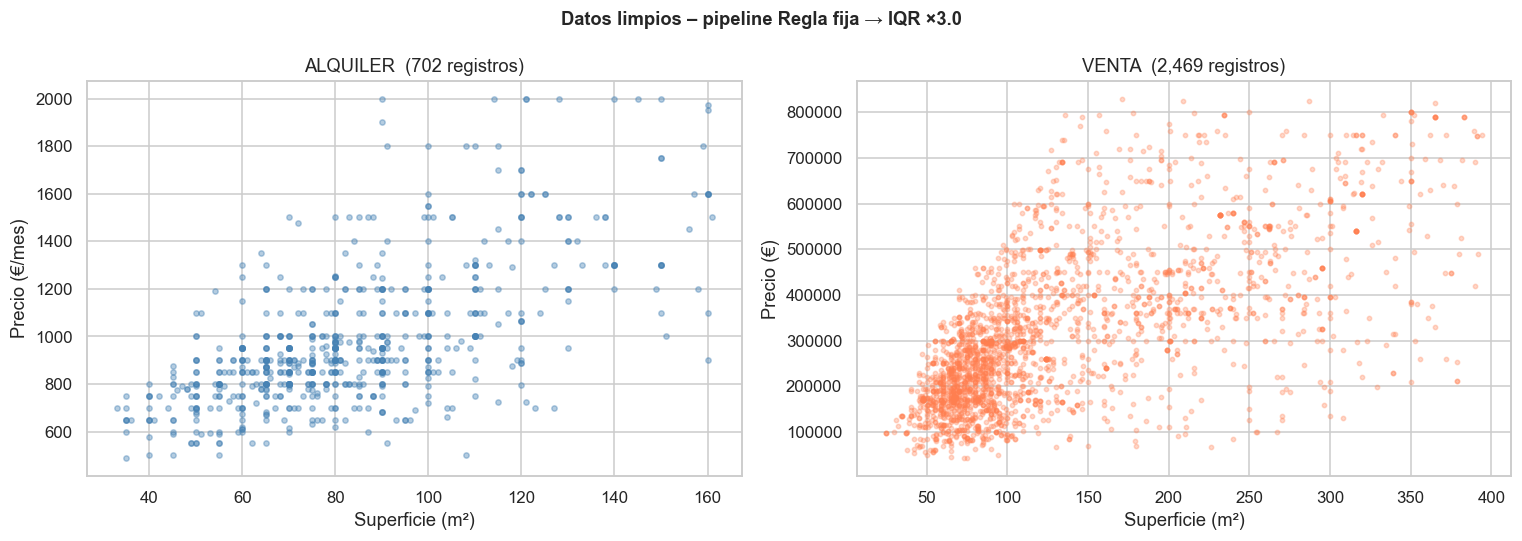

In [20]:
# ── Scatter post-pipeline (validación visual) ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Datos limpios – pipeline Regla fija → IQR ×3.0', fontsize=12, fontweight='bold')

axes[0].scatter(rent_clean['size'], rent_clean['price'], alpha=0.4, s=12, color='steelblue')
axes[0].set_title(f'ALQUILER  ({len(rent_clean):,} registros)')
axes[0].set_xlabel('Superficie (m²)')
axes[0].set_ylabel('Precio (€/mes)')

axes[1].scatter(sale_clean['size'], sale_clean['price'], alpha=0.3, s=8, color='coral')
axes[1].set_title(f'VENTA  ({len(sale_clean):,} registros)')
axes[1].set_xlabel('Superficie (m²)')
axes[1].set_ylabel('Precio (€)')

plt.tight_layout()
plt.show()

In [21]:
# ── Limpiar archivos existentes en processed/idealistaAPI ─────────────────
existing = glob.glob(os.path.join(OUT_DIR, '*.csv'))
for f in existing:
    os.remove(f)
    print(f"  Eliminado: {os.path.basename(f)}")

# ── Exportar resultados del pipeline ──────────────────────────────────────
rent_clean.to_csv(OUT_RENT, index=False)
sale_clean.to_csv(OUT_SALE, index=False)

print(f"\nExportado: {OUT_RENT}  ({len(rent_clean):,} registros)")
print(f"Exportado: {OUT_SALE}  ({len(sale_clean):,} registros)")
print("\nFIN – pipeline de outliers completado.")

  Eliminado: total_rent_cantabria_outliers.csv
  Eliminado: total_sale_cantabria_outliers.csv

Exportado: /Users/sitomachucas/Documents/BezanillaSL/data/processed/idealistaAPI/total_rent_cantabria_outliers.csv  (702 registros)
Exportado: /Users/sitomachucas/Documents/BezanillaSL/data/processed/idealistaAPI/total_sale_cantabria_outliers.csv  (2,469 registros)

FIN – pipeline de outliers completado.
